In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [85]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
C = torch.randn((27, 2))

In [8]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [9]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [11]:
h

tensor([[-0.7945, -0.5688, -0.2236,  ...,  0.9767,  0.4711, -0.0448],
        [-0.9883, -0.8785, -0.9275,  ...,  0.8944,  0.5583, -0.8857],
        [-0.9974, -0.8263, -0.8337,  ...,  0.9994, -0.7904, -0.9927],
        ...,
        [-0.9219, -0.9325,  0.8022,  ...,  1.0000, -0.4363, -0.8525],
        [-0.7657, -0.8046, -0.9553,  ...,  0.9209,  0.6528, -0.9892],
        [-0.8693, -0.8615,  0.8384,  ...,  1.0000, -0.1259,  0.2223]])

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [14]:
logits = h @ W2 + b2

In [15]:
logits.shape

torch.Size([228146, 27])

In [16]:
counts = logits.exp()

In [17]:
prob = counts / counts.sum(1, keepdims = True)

In [18]:
prob.shape

torch.Size([228146, 27])

In [19]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
torch.arange(32)

In [20]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [108]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [130]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [131]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [132]:
for p in parameters:
    p.requires_grad = True

In [133]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [134]:
lri = []
lossi = []
stepi = []

In [149]:

for i in range(50000):
    
    #mini batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #forward pass
    emb = C[Xtr[ix]] #32, 3, 2
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #32, 100
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
#     lr = lrs[i]
    lr = 0.005
    for p in parameters:
        p.data += -lr * p.grad
        
    #track stats
#     lri.append(lr)
    lossi.append(loss.log10().item())
    stepi.append(i)

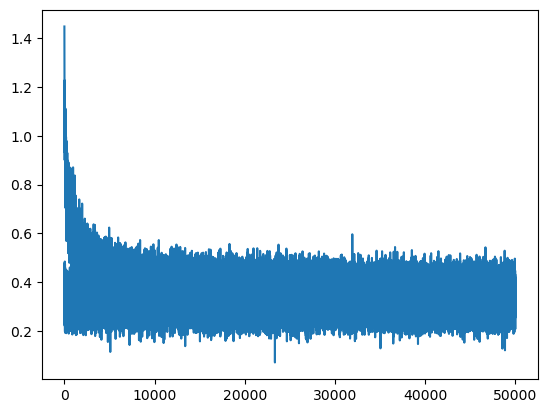

In [150]:
plt.plot(stepi, lossi)

In [151]:
emb = C[Xtr] #32, 3, 2
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #32, 100
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1496, grad_fn=<NllLossBackward0>)

In [152]:
emb = C[Xdev] #32, 3, 2
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #32, 100
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1764, grad_fn=<NllLossBackward0>)

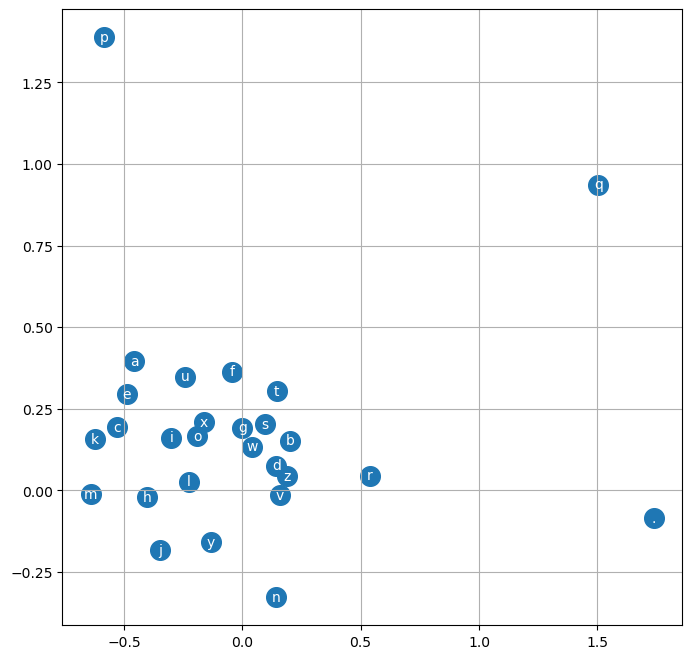

In [153]:

# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')


In [154]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mona.
kayah.
seel.
ndyn.
alee.
thrstendrae.
caileed.
elin.
shi.
jen.
eden.
estanaraelynn.
hone.
cayshabergiaghies.
kindreelle.
jetton.
kubelleder.
yadue.
els.
kaysh.
